<div style="width:100%; background-color:181818; color:f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExd3V1ZXhoNTNtYWJtaWg0YXU3MXRlaHZ3aDZyMnNqMnU2cW45Y3p0byZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/KG4S4T3n2qEqgxBEuV/giphy.gif" alt="Beam Oscillation" width="500" style="border-radius:10px;">

  <h3 style="color:ffffff; margin-top:15px;"><b>Simple code for SDOF in free motion</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Seismic Desing</p>
  <p><b>Year:</b> MARCH - 2026</p>

</div>

## Simple Code for SDOF system in free motion

In [26]:
import sys
print(sys.executable)

/home/normando/Dropbox/Root/Github Repositories/kira/bin/python


### **Libraries**

In [27]:
# %matplotlib widget
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from repo_seismic_desing import *

In [28]:
xo = 3
xvo = 0
wo = 3
dw = 1
wf = 10
to = 0
dt = 0.01
tf = 5

In [29]:
resul = []
w_values = []
T_values = []
f_values = []
for w in np.arange(wo,wf+1,dw):
    T = 2*np.pi / w
    f = 1/T
    simul = Simple_free_motion(xo,xvo,w,to,dt,tf)
    x, t = simul.sim_free_sdof_nodamp()
    resul.append(x)
    w_values.append(w)
    T_values.append(T)
    f_values.append(f)

col_names = [f"Amplitude, w = {w}, T = {T:.3f} [s], f = {f:.3f} [Hz]" for w, T, f in zip(w_values, T_values, f_values)]

X = np.hstack(resul)
tdf = pd.DataFrame(t, columns= ['Time [s]'])
Xdf = pd.DataFrame(X, columns= col_names) 
RES = pd.concat([tdf, Xdf], axis= 1, ignore_index= False)
RES

,Time [s],"Amplitude, w = 3, T = 2.094 [s], f = 0.477 [Hz]","Amplitude, w = 4, T = 1.571 [s], f = 0.637 [Hz]","Amplitude, w = 5, T = 1.257 [s], f = 0.796 [Hz]","Amplitude, w = 6, T = 1.047 [s], f = 0.955 [Hz]","Amplitude, w = 7, T = 0.898 [s], f = 1.114 [Hz]","Amplitude, w = 8, T = 0.785 [s], f = 1.273 [Hz]","Amplitude, w = 9, T = 0.698 [s], f = 1.432 [Hz]","Amplitude, w = 10, T = 0.628 [s], f = 1.592 [Hz]"
0,0.00,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
1,0.01,2.998650,2.997600,2.996251,2.994602,2.992653,2.990405,2.987858,2.985012
2,0.02,2.994602,2.990405,2.985012,2.978426,2.970648,2.961682,2.951531,2.940200
3,0.03,2.987858,2.978426,2.966313,2.951531,2.934093,2.914014,2.891313,2.866009
4,0.04,2.978426,2.961682,2.940200,2.914014,2.883166,2.847706,2.807690,2.763183
...,...,...,...,...,...,...,...,...,...
495,4.95,-1.961939,1.743965,2.782933,-0.433864,-2.987180,-0.972390,2.529415,2.163144
496,4.96,-2.029132,1.644956,2.835452,-0.255082,-2.960487,-1.196081,2.374196,2.359857
497,4.97,-2.094499,1.543314,2.880883,-0.075383,-2.919293,-1.412121,2.199758,2.532991
498,4.98,-2.157981,1.439204,2.919113,0.104588,-2.863801,-1.619128,2.007515,2.680815


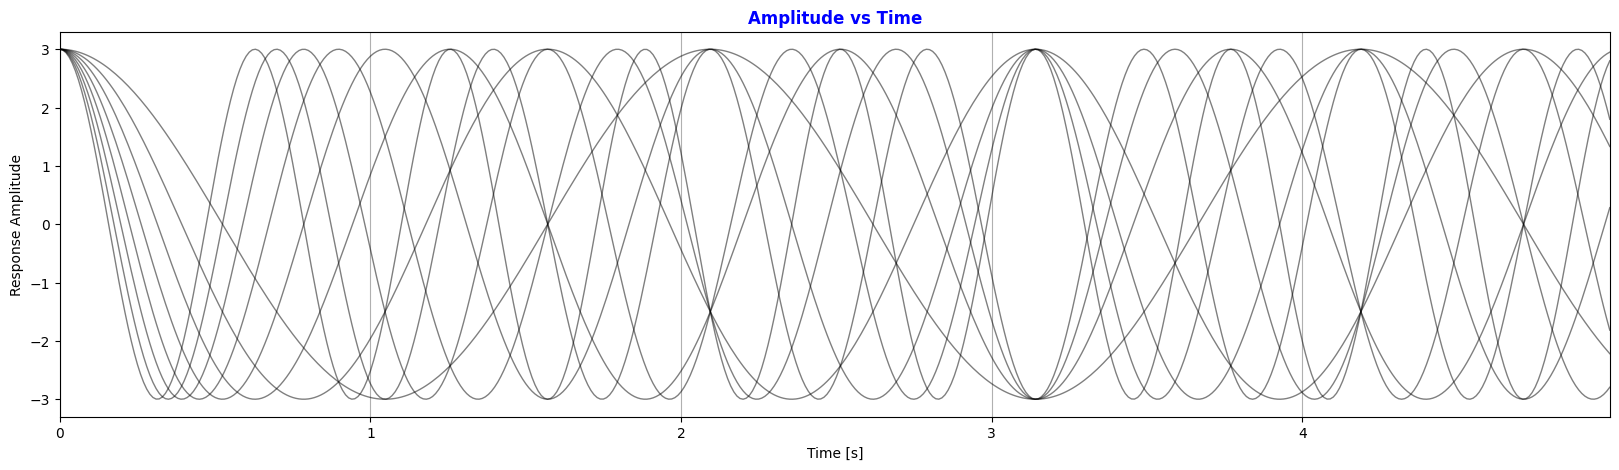

In [30]:
PLTExamp1 = plt_amp_tim(X, t, color = [0, 0, 0], title = 'Amplitude vs Time')
PLTExamp1.plot_Avst()